<a href="https://colab.research.google.com/github/Colosolizer/carisurg-portfolio/blob/setup-folders/notebooks/Week6_Model_Evaluation_SekouRuddock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTEBOOK SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries loaded. Time to cook!!")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)




Libraries loaded. Time to cook!!


# MOUNT GOOGLE DRIVE

In [2]:
#Import Dataset from google drive
from pathlib import Path
from google.colab import drive; drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/ColabNotebooks/Carisurg_2026/triage_cleaned_v1.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Unable to find {DATA_PATH}.")

Mounted at /content/drive


# LOAD CLEANED DATASET

In [3]:
df = pd.read_csv(DATA_PATH, index_col=0)
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 55121 patients and 224 columns.


,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
dep_name,,,,,,,,,,,,,,,,,,,,,
A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# RELOADING SAVED MODEL

In [4]:
#LOAD MODELS FROM GOOGLE DRIVE INTO PATH VARIABLE
model_folder_path = Path("/content/drive/MyDrive/ColabNotebooks/Week6_models")
logreg_model_path = model_folder_path / "model_logreg.joblib"
tree_model_path   = model_folder_path / "model_tree.joblib"
scaler_model_path = model_folder_path / "scaler.joblib"

#LOAD MODEL ITSELF
tree_reloaded   = joblib.load(tree_model_path)     # the trained decision tree
scaler_reloaded = joblib.load(scaler_model_path)         # the SAME scaler used in training
logreg_reloaded = joblib.load(logreg_model_path)
print("Models loaded. ✅")

Models loaded. ✅


# PREDICTION ON TEST SET

In [10]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is:
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

In [11]:
X, y = df[FEATURES], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Logistic regression needs scaling; the tree does not.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [13]:
pred_logreg = logreg_reloaded.predict(X_test_s)   # scaled features for LR
pred_tree   = tree_reloaded.predict(X_test)       # unscaled for the tree
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]


# CONFUSION MATRIX

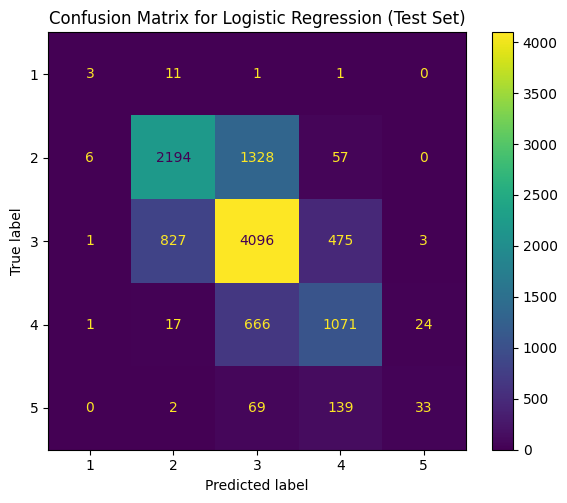

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax)
ax.set_title("Confusion Matrix for Logistic Regression (Test Set)")
plt.tight_layout()
plt.show()

# Accuracy, precision, recall, F1

In [15]:
print(classification_report(y_test, pred_logreg, digits=3))

              precision    recall  f1-score   support

           1      0.273     0.188     0.222        16
           2      0.719     0.612     0.661      3585
           3      0.665     0.758     0.709      5402
           4      0.614     0.602     0.608      1779
           5      0.550     0.136     0.218       243

    accuracy                          0.671     11025
   macro avg      0.564     0.459     0.484     11025
weighted avg      0.671     0.671     0.665     11025



# Macro vs weighted F1

In [16]:
macro_f1 = f1_score(y_test, pred_logreg, average="macro")
weighted_f1 = f1_score(y_test, pred_logreg, average="weighted")

print(f"Macro F1-score: {macro_f1:.3f}")
print(f"Weighted F1-score: {weighted_f1:.3f}")

Macro F1-score: 0.484
Weighted F1-score: 0.665


# Recall for ESI 1

In [17]:
recall_logreg_esi1 = recall_score(y_test, pred_logreg, labels=[1], average=None)[0]
recall_tree_esi1 = recall_score(y_test, pred_tree, labels=[1], average=None)[0]

print(f"Logistic Regression ESI-1 Recall: {recall_logreg_esi1:.3f}")
print(f"Decision Tree ESI-1 Recall: {recall_tree_esi1:.3f}")

Logistic Regression ESI-1 Recall: 0.188
Decision Tree ESI-1 Recall: 0.000


# Model Comparison

In [19]:
dummy  = DummyClassifier(strategy="stratified", random_state=42).fit(X_train, y_train)

In [21]:
def summarise(name, preds):
    return {
        "model": name,
        "accuracy": round((preds == y_test).mean(), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None)[0], 3),
    }

table = pd.DataFrame([
    summarise("Dummy (baseline)", dummy.predict(X_test)),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree", tree_reloaded.predict(X_test)),
])
table

,model,accuracy,macro_F1,recall_ESI1
0,Dummy (baseline),0.375,0.204,0.000
1,Logistic Regression,0.671,0.484,0.188
2,Decision Tree,0.556,0.216,0.000


# Save Confusion Matrix

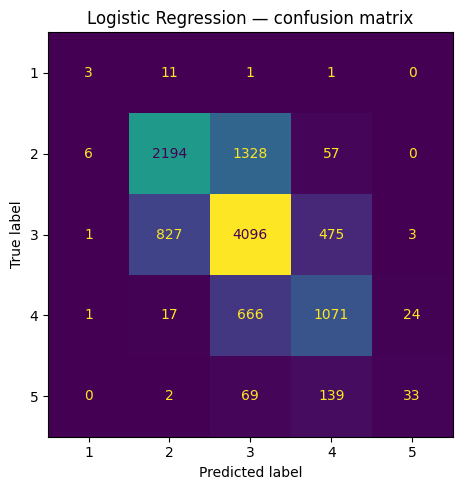

Saved figs/w6_confusion_logreg.png ✅


In [22]:
import os
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False)
ax.set_title("Logistic Regression — confusion matrix")
plt.tight_layout()
plt.savefig("figs/w6_confusion_logreg.png", dpi=110)
plt.show()
print("Saved figs/w6_confusion_logreg.png ✅")